In [ ]:
import os
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF

In [3]:
BASE_DIR = Path.cwd()
DATASET_DIR = BASE_DIR / "tiny-imagenet-200"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

STATS_FILE  = RESULTS_DIR / "dataset_stats.json"
TRAIN_DIR   = DATASET_DIR / "train"
VAL_DIR     = DATASET_DIR / "val"
VAL_ANNOT   = VAL_DIR / "val_annotations.txt"
WNIDS_FILE  = DATASET_DIR / "wnids.txt"

In [4]:
if STATS_FILE.exists():
    with open(STATS_FILE) as f:
        s = json.load(f)
    MEAN = tuple(s["rgb_mean"])
    STD  = tuple(s["rgb_std"])
    print(f"Loaded mean/std from {STATS_FILE.name}")
else:
    MEAN = (0.4802, 0.4481, 0.3975)
    STD  = (0.2770, 0.2691, 0.2821)
    print("⚠  dataset_stats.json not found — using published reference values. Run eda.py first!")

print(f"  mean = {MEAN}")
print(f"  std  = {STD}")

Loaded mean/std from dataset_stats.json
  mean = (0.4835889935493469, 0.4504620134830475, 0.400054007768631)
  std  = (0.27578800916671753, 0.2674590051174164, 0.2805129885673523)


In [5]:
with open(WNIDS_FILE) as f:
    wnids = [l.strip() for l in f if l.strip()]

CLASS_MAP   = {wnid: idx for idx, wnid in enumerate(sorted(wnids))}
NUM_CLASSES = len(CLASS_MAP)
print(f"  #classes = {NUM_CLASSES}")

  #classes = 200


In [6]:
train_transform = T.Compose([
    T.RandomCrop(64, padding=8, padding_mode="reflect"),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.RandomErasing(p=0.2, scale=(0.02, 0.10), ratio=(0.3, 3.3), value=0),
    T.Normalize(mean=MEAN, std=STD),
])

val_transform = T.Compose([
    T.CenterCrop(56),
    T.Resize(64, interpolation=T.InterpolationMode.BILINEAR, antialias=True),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

print("Augmentation strategy:")
print("  TRAIN : RandomCrop(64, pad=8) | HFlip(0.5) | ColorJitter | RandomGrayscale | RandomErasing(0.2) | Normalize")
print("  VAL   : CenterCrop(56) → Resize(64) | Normalize")

Augmentation strategy:
  TRAIN : RandomCrop(64, pad=8) | HFlip(0.5) | ColorJitter | RandomGrayscale | RandomErasing(0.2) | Normalize
  VAL   : CenterCrop(56) → Resize(64) | Normalize


In [7]:
class TinyImageNetTrain(Dataset):
    def __init__(self, transform=None):
        self.transform = transform or train_transform
        self.samples: list[tuple[Path, int]] = []
        for wnid, label in CLASS_MAP.items():
            img_dir = TRAIN_DIR / wnid / "images"
            if img_dir.exists():
                for p in img_dir.glob("*.JPEG"):
                    self.samples.append((p, label))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.transform(Image.open(path).convert("RGB")), label

In [8]:
class TinyImageNetVal(Dataset):
    def __init__(self, transform=None):
        self.transform = transform or val_transform
        self.samples: list[tuple[Path, int]] = []
        img_dir = VAL_DIR / "images"
        with open(VAL_ANNOT) as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) >= 2 and parts[1] in CLASS_MAP:
                    self.samples.append((img_dir / parts[0], CLASS_MAP[parts[1]]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.transform(Image.open(path).convert("RGB")), label

In [10]:
def get_dataloaders(batch_size=128, num_workers=None, pin_memory=True,
                    train_tf=None, val_tf=None):
    if num_workers is None:
        num_workers = max(1, (os.cpu_count() or 4) - 1)

    train_loader = DataLoader(
        TinyImageNetTrain(transform=train_tf),
        batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
        drop_last=True,
    )
    val_loader = DataLoader(
        TinyImageNetVal(transform=val_tf),
        batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
        drop_last=False,
    )
    return train_loader, val_loader


NUM_WORKERS = max(1, (os.cpu_count() or 4) - 1)
print(f"DataLoader config:")
print(f"  num_workers = {NUM_WORKERS} | pin_memory = True | batch_size = 128 | drop_last = True")

DataLoader config:
  num_workers = 3 | pin_memory = True | batch_size = 128 | drop_last = True


Generating augmentation preview …


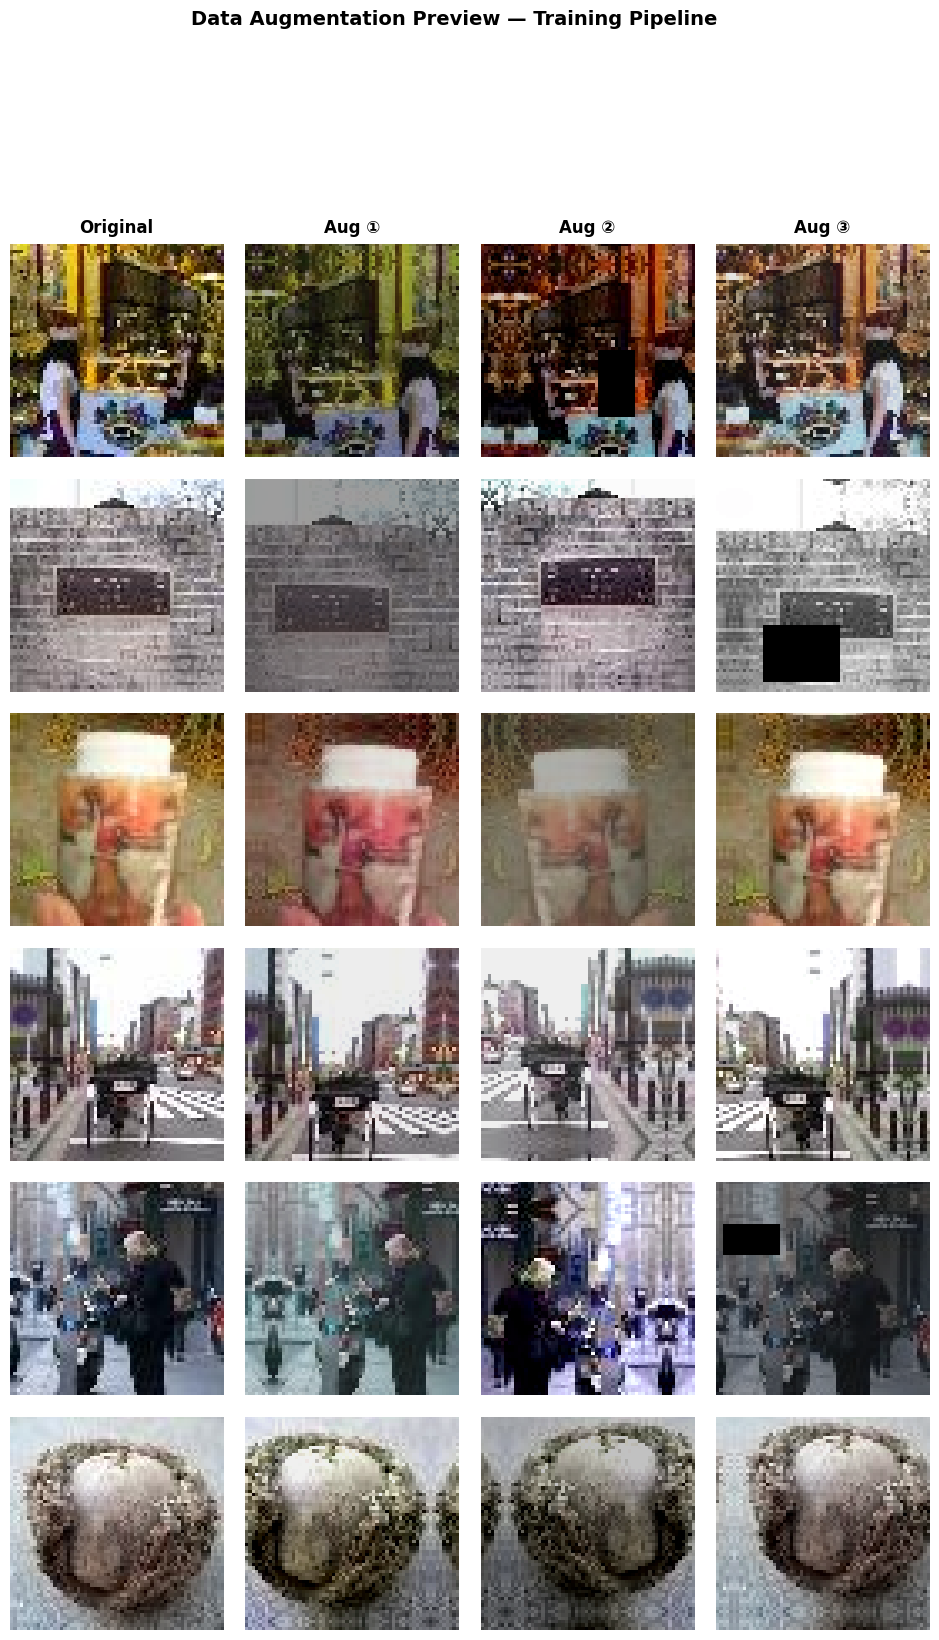

Saved → augmentation_preview.png


In [ ]:
print("Generating augmentation preview …")

N_SAMPLES  = 6
train_ds   = TinyImageNetTrain()
indices    = random.sample(range(len(train_ds)), N_SAMPLES)

fig, axes = plt.subplots(N_SAMPLES, 4, figsize=(12, N_SAMPLES * 3),
                          gridspec_kw={"hspace": 0.1, "wspace": 0.05})
for col, title in enumerate(["Original", "Aug ①", "Aug ②", "Aug ③"]):
    axes[0, col].set_title(title, fontsize=12, pad=8, fontweight="bold")

_mean_t = torch.tensor(MEAN).view(3, 1, 1)
_std_t  = torch.tensor(STD).view(3, 1, 1)

for row, idx in enumerate(indices):
    path, _ = train_ds.samples[idx]
    pil_img = Image.open(path).convert("RGB")

    # Original
    raw = (T.ToTensor()(pil_img).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    axes[row, 0].imshow(raw)
    axes[row, 0].axis("off")

    # Three augmented views
    for col in range(1, 4):
        aug = train_transform(pil_img)
        denorm = ((aug * _std_t + _mean_t).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        axes[row, col].imshow(denorm)
        axes[row, col].axis("off")

fig.suptitle("Data Augmentation Preview — Training Pipeline",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(RESULTS_DIR / "augmentation_preview.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Saved augmentation_preview.png")

In [ ]:
print("Benchmarking DataLoader (batch=128, 20 batches) …")

train_loader, _ = get_dataloaders(batch_size=128)
loader_iter     = iter(train_loader)
_ = next(loader_iter)   # warm-up

t0, n_imgs = time.perf_counter(), 0
for _ in range(min(20, len(train_loader))):
    imgs, _ = next(loader_iter)
    n_imgs += imgs.shape[0]
elapsed    = time.perf_counter() - t0
throughput = n_imgs / elapsed

bm = {
    "batch_size":       128,
    "num_workers":      NUM_WORKERS,
    "n_batches":        20,
    "total_images":     n_imgs,
    "elapsed_sec":      round(elapsed, 3),
    "throughput_img_s": round(throughput, 1),
}

print(f"  Throughput : {throughput:,.0f} imgs/sec")
print(f"  Workers    : {NUM_WORKERS}")
print(f"  Elapsed    : {elapsed:.2f}s for {n_imgs:,} images")
print(f"  Results    : {json.dumps(bm, indent=2)}")

with open(RESULTS_DIR / "dataloader_benchmark.json", "w") as f:
    json.dump(bm, f, indent=2)

Benchmarking DataLoader (batch=128, 20 batches) …
